In [ ]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np


def short_node_label(raw):
    text = str(raw)
    if "Root" in text:
        return "Root"
    import re

    m = re.search(r"LE(\d+).*CS\1", text)
    if m:
        return f"LE/CS{m.group(1)}"
    m = re.search(r"OT(\d+)_m(\d+)", text)
    if m:
        return f"OT{m.group(1)}\nm{m.group(2)}"
    m = re.search(r"OT(\d+)-(\d+) and R", text)
    if m:
        return f"OT{m.group(1)}-{m.group(2)}\n+R"
    m = re.search(r"OT(\d+) and R", text)
    if m:
        return f"OT{m.group(1)}\n+R"
    m = re.search(r"OT(\d+)-(\d+) and F", text)
    if m:
        return f"OT{m.group(1)}-{m.group(2)}\n+F"
    m = re.search(r"OT(\d+)-(\d+)", text)
    if m:
        return f"OT{m.group(1)}-{m.group(2)}"
    if "F modes" in text:
        return "F\nmodes"
    m = re.search(r"OT(\d+).*modes", text)
    if m:
        return f"OT{m.group(1)}\nmodes"
    m = re.search(r"OT(\d+)", text)
    if m:
        return f"OT{m.group(1)}"
    if re.search(r"'R'", text):
        return "R"
    m = re.search(r"F(\d+)", text)
    if m:
        return f"F{m.group(1)}"
    return re.sub(r"[\[\]\(\)',]", "", text).replace("TreeX", "").strip() or text


def tree_layout(children, root=0):
    leaf_counts = {}

    def count_leaves(node):
        if node in leaf_counts:
            return leaf_counts[node]
        if len(children[node]) == 0:
            leaf_counts[node] = 1
        else:
            leaf_counts[node] = sum(count_leaves(child) for child in children[node])
        return leaf_counts[node]

    count_leaves(root)
    pos = {}
    max_depth = 0

    def assign(node, left, right, depth):
        nonlocal max_depth
        max_depth = max(max_depth, depth)
        pos[node] = ((left + right) / 2.0, -float(depth))
        cursor = left
        total = sum(leaf_counts[child] for child in children[node])
        for child in children[node]:
            width = (right - left) * leaf_counts[child] / total if total else 0.0
            assign(child, cursor, cursor + width, depth + 1)
            cursor += width

    assign(root, 0.0, float(leaf_counts[root]), 0)
    return pos, leaf_counts[root], max_depth


def format_entropy(value):
    if abs(value) < 1e-12:
        return "0"
    if abs(value) < 1e-3:
        return f"{value:.1e}"
    return f"{value:.3f}".rstrip("0").rstrip(".")


def plot_bond_entropy(npz_path, time_fs, save_path=None, show=True):
    npz_path = Path(npz_path).expanduser()
    npz = np.load(npz_path, allow_pickle=True)
    times = np.asarray(npz["time_fs"], dtype=float)
    if not (times.min() <= time_fs <= times.max()):
        raise ValueError(f"time_fs must be between {times.min()} and {times.max()}, got {time_fs}")

    time_idx = int(np.argmin(np.abs(times - time_fs)))
    actual_time = float(times[time_idx])
    raw_labels = [str(x) for x in npz["dof_strs"]]
    adj = np.asarray(npz["adj_matrix"])
    bond_entropy = np.asarray(npz["S_bond_entropy"], dtype=float)[time_idx]

    children = {idx: list(np.flatnonzero(adj[idx])) for idx in range(len(raw_labels))}
    edges = [(parent, child) for parent, child_list in children.items() for child in child_list]
    edge_entropies = np.array([bond_entropy[child] for _, child in edges], dtype=float)

    pos, n_leaves, max_depth = tree_layout(children, root=0)
    vmax = max(float(np.nanmax(edge_entropies)), 1e-12)
    norm = mpl.colors.Normalize(vmin=0.0, vmax=vmax)
    cmap = plt.get_cmap("magma")

    fig_w = max(18, n_leaves * 0.24)
    fig_h = max(10, (max_depth + 1) * 0.85)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h), constrained_layout=True)

    for (parent, child), entropy in zip(edges, edge_entropies):
        x0, y0 = pos[parent]
        x1, y1 = pos[child]
        ax.plot(
            [x0, x1], [y0, y1],
            color=cmap(norm(entropy)),
            linewidth=1.15,
            solid_capstyle="round",
            zorder=1,
        )

        xm, ym = (x0 + x1) / 2.0, (y0 + y1) / 2.0
        dx, dy = x1 - x0, y1 - y0
        length = float(np.hypot(dx, dy))
        if length > 0:
            nx, ny = -dy / length, dx / length
            if ny < 0:
                nx, ny = -nx, -ny
        else:
            nx, ny = 0.0, 1.0
        ax.text(
            xm + 0.08 * nx, ym + 0.08 * ny, format_entropy(float(entropy)),
            ha="center", va="center",
            fontsize=4.2,
            color="#111111",
            bbox={"boxstyle": "round,pad=0.08", "facecolor": "white", "edgecolor": "none", "alpha": 0.72},
            zorder=2,
        )

    for idx, raw in enumerate(raw_labels):
        x, y = pos[idx]
        ax.text(
            x, y, short_node_label(raw),
            ha="center", va="center",
            fontsize=5.2,
            linespacing=0.92,
            bbox={"boxstyle": "round,pad=0.18", "facecolor": "white", "edgecolor": "#222222", "linewidth": 0.35},
            zorder=3,
        )

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.018, pad=0.01)
    cbar.set_label("Bond entropy S")

    ax.set_title(
        f"Singleset TreeX bond entropy at t={actual_time:g} fs\n"
        f"edge color = entropy of the child-node bond; source npz: {npz_path.name}",
        fontsize=12,
    )
    ax.set_axis_off()
    ax.margins(x=0.02, y=0.06)

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    if show:
        plt.show()
    return fig, ax


NPZ_PATH = Path("/curie-home/zengjj/Renormalizer/multiset_ttn/P3HT:PCBM/singleset_treeX/p3ht_ttns_treeX_bond_entropy_32.npz")
TIME_FS = 200

plot_bond_entropy(NPZ_PATH, TIME_FS)


Parsed 250 bond entropy entries from P3HT_singleset_treeX_m64.log
Saved figure to /curie-home/zengjj/Renormalizer/multiset_ttn/P3HT:PCBM/plot/singleset_treeX_bond_entropy_step200_M64.pdf


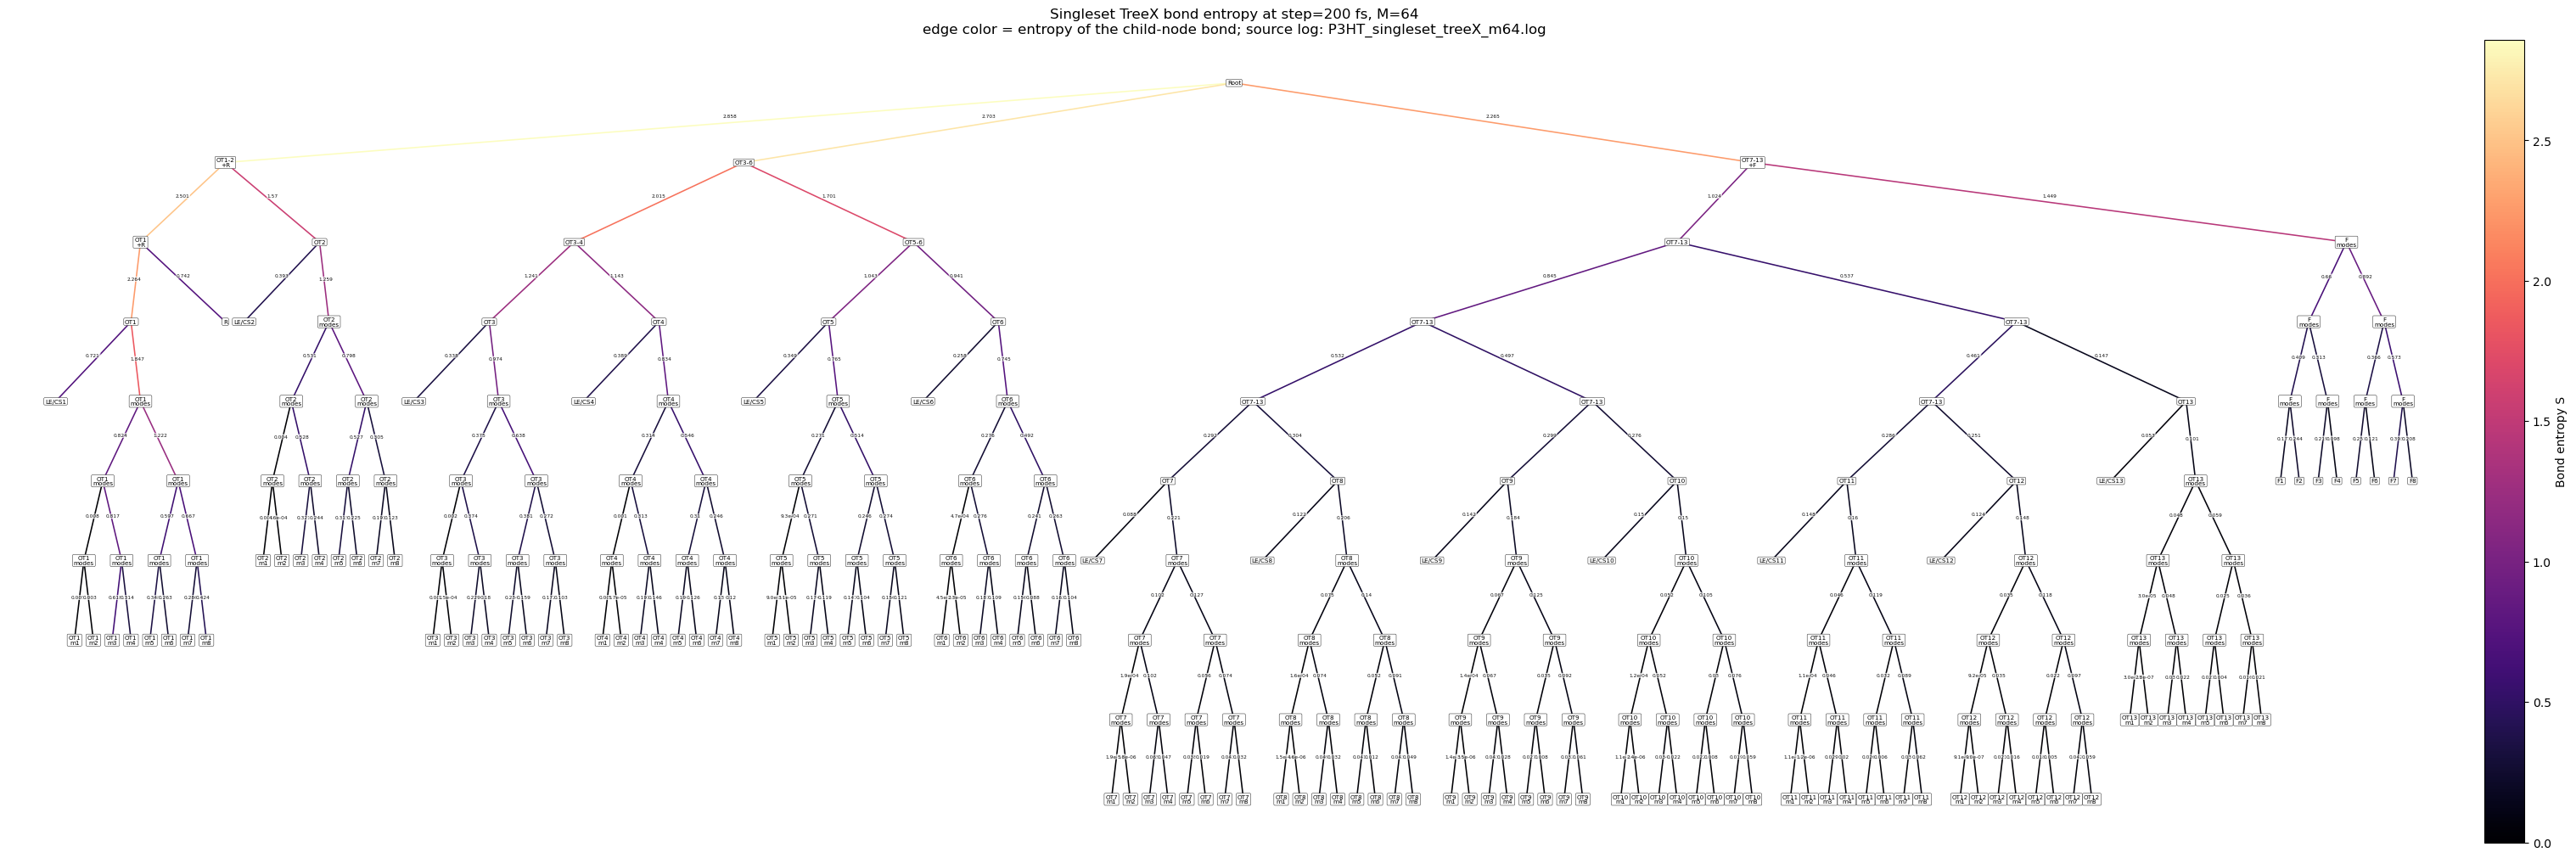

In [2]:


STEP = 200


def find_singleset_treeX_dir():
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / "singleset_treeX",
        cwd.parent / "singleset_treeX",
        cwd / "multiset_ttn" / "P3HT:PCBM" / "singleset_treeX",
    ]
    candidates.extend(parent / "multiset_ttn" / "P3HT:PCBM" / "singleset_treeX" for parent in [cwd, *cwd.parents])
    for path in candidates:
        if path.exists():
            return path.resolve()
    raise FileNotFoundError("Cannot find multiset_ttn/P3HT:PCBM/singleset_treeX from the current notebook directory")


def choose_log_and_npz(data_dir, step=STEP):
    matches = []
    for log_path in sorted(data_dir.glob("P3HT_singleset_treeX_m*.log")):
        text = log_path.read_text(errors="replace")
        if f"bond entropy tree dump step={step}" not in text:
            continue
        m = re.search(r"_m(\d+)\.log$", log_path.name)
        max_bonddim = int(m.group(1)) if m else -1
        npz_path = data_dir / f"p3ht_ttns_treeX_bond_entropy_{max_bonddim}.npz"
        matches.append((npz_path.exists(), max_bonddim, log_path, npz_path))
    if not matches:
        raise FileNotFoundError(f"No singleset TreeX log contains bond entropy tree dump step={step}")
    has_npz, max_bonddim, log_path, npz_path = sorted(matches, reverse=True)[0]
    if not has_npz:
        raise FileNotFoundError(f"Found {log_path.name}, but cannot find matching {npz_path.name}")
    return max_bonddim, log_path, npz_path


def strip_log_prefix(line):
    if "[INFO]" in line:
        return line.split("[INFO]", 1)[1]
    return line


def parse_bond_entropy_tree(log_path, step=STEP):
    lines = log_path.read_text(errors="replace").splitlines()
    marker = f"bond entropy tree dump step={step}"
    try:
        start = next(i for i, line in enumerate(lines) if marker in line)
    except StopIteration as exc:
        raise ValueError(f"{marker!r} not found in {log_path}") from exc

    block = []
    for line in lines[start + 1:]:
        payload = strip_log_prefix(line).rstrip()
        if "bond entropy tree dump" in payload and block:
            break
        block.append(payload)

    entry_re = re.compile(
        r"(\[[^\]]+\])\s+"
        r"([-+]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][-+]?\d+)?|-0(?:\.0*)?)"
    )
    entropy_by_label = {}
    for line in block:
        for label, value in entry_re.findall(line):
            entropy = float(value)
            if entropy == 0.0:
                entropy = 0.0
            entropy_by_label[label] = entropy
    if not entropy_by_label:
        raise ValueError(f"No bond entropy entries parsed from {log_path.name} at step={step}")
    return entropy_by_label


def short_node_label(raw):
    text = str(raw)
    if "Root" in text:
        return "Root"
    m = re.search(r"LE(\d+).*CS\1", text)
    if m:
        return f"LE/CS{m.group(1)}"
    m = re.search(r"OT(\d+)_m(\d+)", text)
    if m:
        return f"OT{m.group(1)}\nm{m.group(2)}"
    m = re.search(r"OT(\d+)-(\d+) and R", text)
    if m:
        return f"OT{m.group(1)}-{m.group(2)}\n+R"
    m = re.search(r"OT(\d+) and R", text)
    if m:
        return f"OT{m.group(1)}\n+R"
    m = re.search(r"OT(\d+)-(\d+) and F", text)
    if m:
        return f"OT{m.group(1)}-{m.group(2)}\n+F"
    m = re.search(r"OT(\d+)-(\d+)", text)
    if m:
        return f"OT{m.group(1)}-{m.group(2)}"
    if "F modes" in text:
        return "F\nmodes"
    m = re.search(r"OT(\d+).*modes", text)
    if m:
        return f"OT{m.group(1)}\nmodes"
    m = re.search(r"OT(\d+)", text)
    if m:
        return f"OT{m.group(1)}"
    if re.search(r"'R'", text):
        return "R"
    m = re.search(r"F(\d+)", text)
    if m:
        return f"F{m.group(1)}"
    return re.sub(r"[\[\]\(\)',]", "", text).replace("TreeX", "").strip() or text


def tree_layout(children, root=0):
    leaf_counts = {}

    def count_leaves(node):
        if node in leaf_counts:
            return leaf_counts[node]
        if len(children[node]) == 0:
            leaf_counts[node] = 1
        else:
            leaf_counts[node] = sum(count_leaves(child) for child in children[node])
        return leaf_counts[node]

    count_leaves(root)
    pos = {}
    max_depth = 0

    def assign(node, left, right, depth):
        nonlocal max_depth
        max_depth = max(max_depth, depth)
        pos[node] = ((left + right) / 2.0, -float(depth))
        cursor = left
        total = sum(leaf_counts[child] for child in children[node])
        for child in children[node]:
            width = (right - left) * leaf_counts[child] / total if total else 0.0
            assign(child, cursor, cursor + width, depth + 1)
            cursor += width

    assign(root, 0.0, float(leaf_counts[root]), 0)
    return pos, leaf_counts[root], max_depth


data_dir = find_singleset_treeX_dir()
max_bonddim, log_path, npz_path = choose_log_and_npz(data_dir, STEP)
entropy_by_label = parse_bond_entropy_tree(log_path, STEP)
npz = np.load(npz_path, allow_pickle=True)
raw_labels = [str(x) for x in npz["dof_strs"]]
adj = np.asarray(npz["adj_matrix"])

entropies = np.array([entropy_by_label.get(label, np.nan) for label in raw_labels], dtype=float)
missing = [label for label, entropy in zip(raw_labels, entropies) if np.isnan(entropy)]
if missing:
    raise ValueError(f"{len(missing)} labels in npz were not found in the parsed log block. Examples: {missing[:5]}")

children = {idx: list(np.flatnonzero(adj[idx])) for idx in range(len(raw_labels))}
edges = [(parent, child) for parent, child_list in children.items() for child in child_list]
edge_entropies = np.array([entropies[child] for _, child in edges], dtype=float)

pos, n_leaves, max_depth = tree_layout(children, root=0)
vmax = max(float(np.nanmax(edge_entropies)), 1e-12)
norm = mpl.colors.Normalize(vmin=0.0, vmax=vmax)
cmap = plt.get_cmap("magma")

fig_w = max(18, n_leaves * 0.24)
fig_h = max(10, (max_depth + 1) * 0.85)
fig, ax = plt.subplots(figsize=(fig_w, fig_h), constrained_layout=True)

def format_entropy(value):
    if abs(value) < 1e-12:
        return "0"
    if abs(value) < 1e-3:
        return f"{value:.1e}"
    return f"{value:.3f}".rstrip("0").rstrip(".")


for (parent, child), entropy in zip(edges, edge_entropies):
    x0, y0 = pos[parent]
    x1, y1 = pos[child]
    strength = norm(entropy)
    ax.plot(
        [x0, x1], [y0, y1],
        color=cmap(strength),
        linewidth=1.15,
        solid_capstyle="round",
        zorder=1,
    )

    xm, ym = (x0 + x1) / 2.0, (y0 + y1) / 2.0
    dx, dy = x1 - x0, y1 - y0
    length = float(np.hypot(dx, dy))
    if length > 0:
        nx, ny = -dy / length, dx / length
        if ny < 0:
            nx, ny = -nx, -ny
    else:
        nx, ny = 0.0, 1.0
    ax.text(
        xm + 0.08 * nx, ym + 0.08 * ny, format_entropy(float(entropy)),
        ha="center", va="center",
        fontsize=4.2,
        color="#111111",
        bbox={"boxstyle": "round,pad=0.08", "facecolor": "white", "edgecolor": "none", "alpha": 0.72},
        zorder=2,
    )

for idx, raw in enumerate(raw_labels):
    x, y = pos[idx]
    ax.text(
        x, y, short_node_label(raw),
        ha="center", va="center",
        fontsize=5.2,
        linespacing=0.92,
        bbox={"boxstyle": "round,pad=0.18", "facecolor": "white", "edgecolor": "#222222", "linewidth": 0.35},
        zorder=3,
    )

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.018, pad=0.01)
cbar.set_label("Bond entropy S")

ax.set_title(
    f"Singleset TreeX bond entropy at step={STEP} fs, M={max_bonddim}\n"
    f"edge color = entropy of the child-node bond; source log: {log_path.name}",
    fontsize=12,
)
ax.set_axis_off()
ax.margins(x=0.02, y=0.06)

out_pdf = data_dir.parent / "plot" / f"singleset_treeX_bond_entropy_step{STEP}_M{max_bonddim}.pdf"
fig.savefig(out_pdf, dpi=300, bbox_inches="tight")
print(f"Parsed {len(entropy_by_label)} bond entropy entries from {log_path.name}")
print(f"Saved figure to {out_pdf}")
plt.show()


Parsed 173 bond entropy entries from P3HT_singleset_tree_m16.log
Saved figure to /curie-home/zengjj/Renormalizer/multiset_ttn/P3HT:PCBM/plot/singleset_tree_bond_entropy_step200_M16.pdf


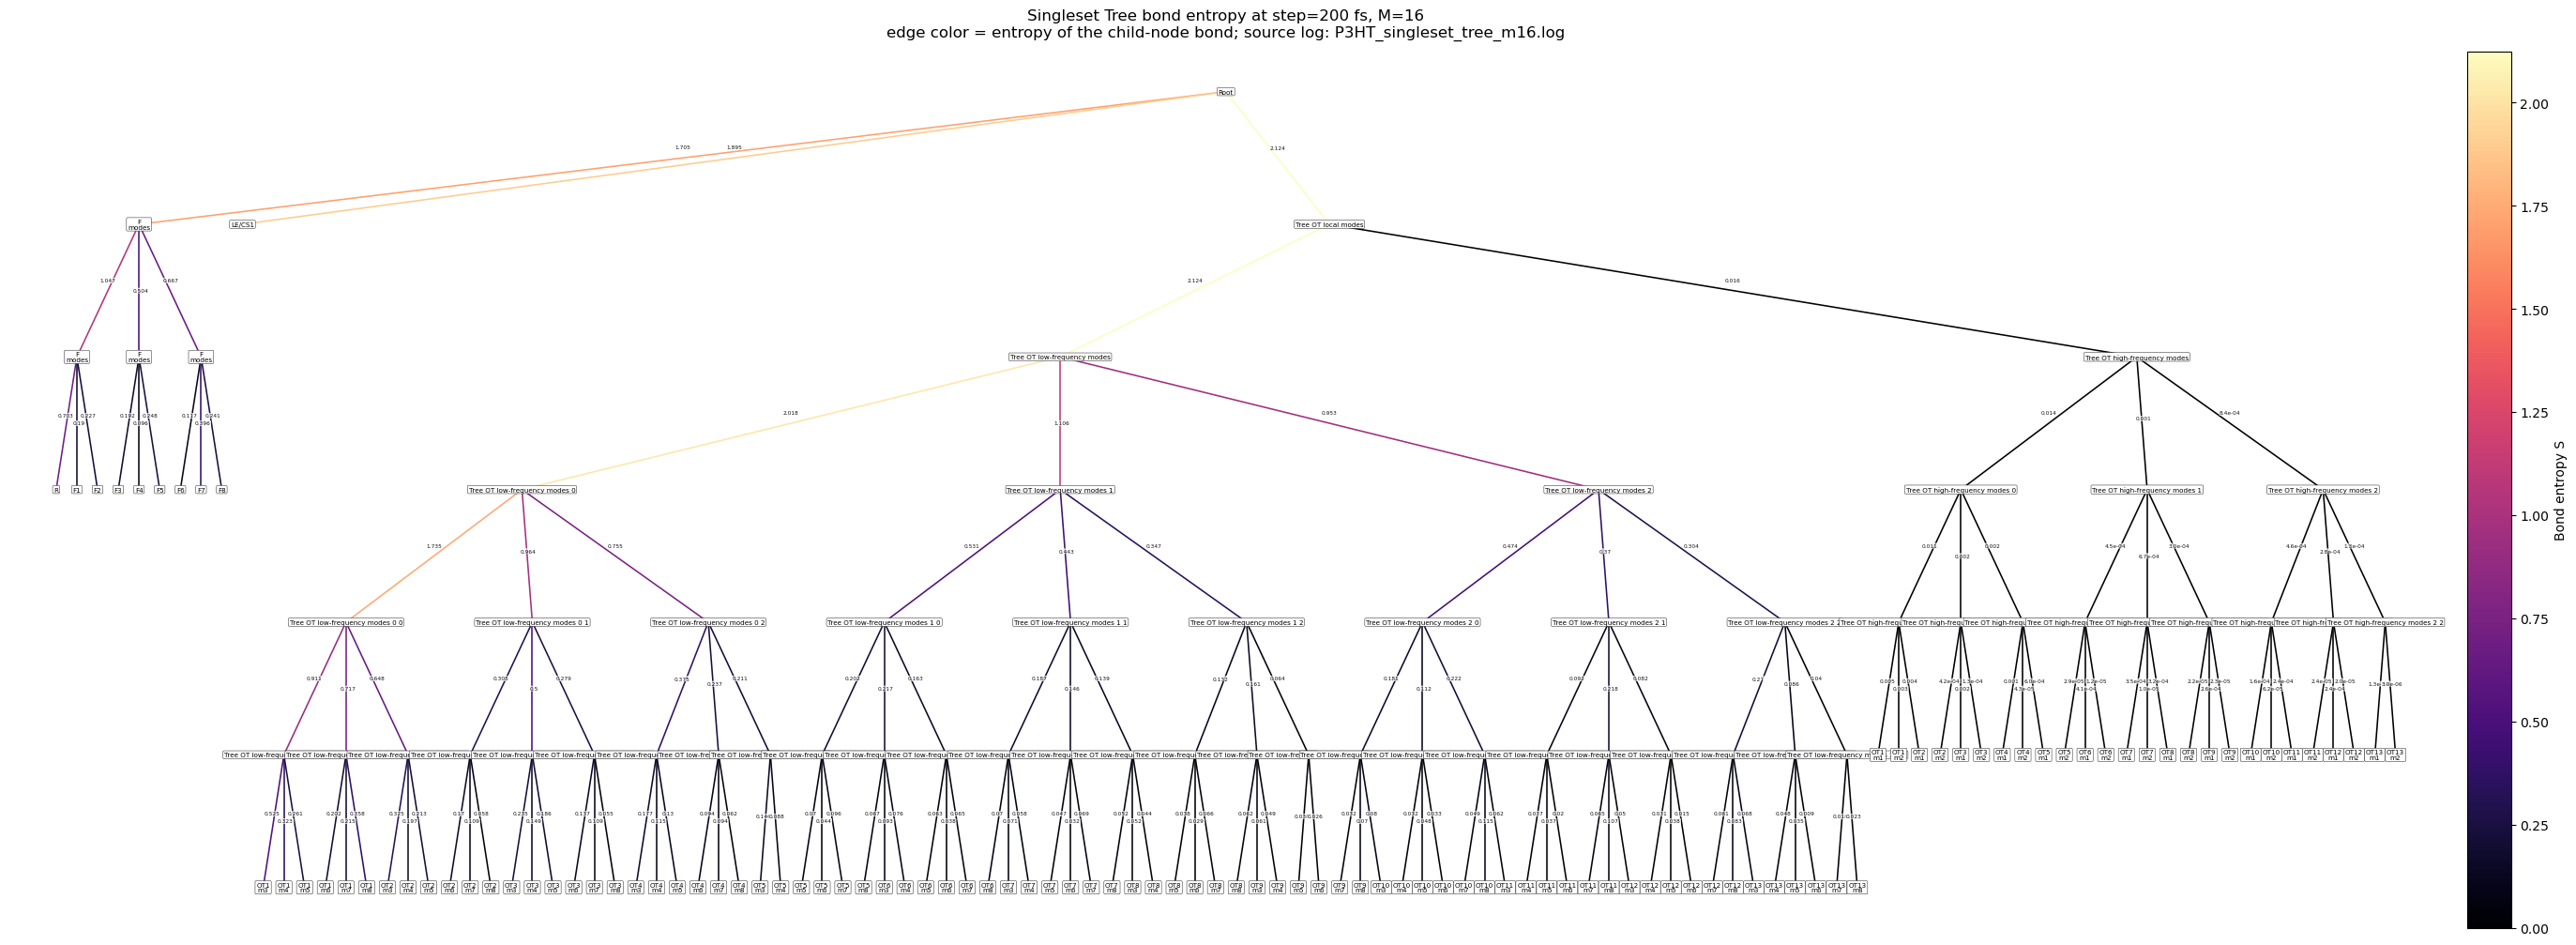

In [3]:
# Plot singleset Tree bond entropy as a full tree PDF.
# This uses the full bond-entropy tree dump from singleset_tree logs.


def find_singleset_tree_dir():
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / "singleset_tree",
        cwd.parent / "singleset_tree",
        cwd / "multiset_ttn" / "P3HT:PCBM" / "singleset_tree",
    ]
    candidates.extend(parent / "multiset_ttn" / "P3HT:PCBM" / "singleset_tree" for parent in [cwd, *cwd.parents])
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError("Cannot find multiset_ttn/P3HT:PCBM/singleset_tree from the current notebook directory")


def choose_singleset_tree_log_and_npz(data_dir, step=STEP):
    matches = []
    for log_path in sorted(data_dir.glob("P3HT_singleset_tree_m*.log")):
        text = log_path.read_text(errors="replace")
        if f"bond entropy tree dump step={step}" not in text:
            continue
        m = re.search(r"_m(\d+)\.log$", log_path.name)
        max_bonddim = int(m.group(1)) if m else -1
        npz_path = data_dir / f"p3ht_ttns_tree_bond_entropy_{max_bonddim}.npz"
        matches.append((npz_path.exists(), max_bonddim, log_path, npz_path))
    if not matches:
        raise FileNotFoundError(f"No singleset Tree log contains bond entropy tree dump step={step}")
    has_npz, max_bonddim, log_path, npz_path = sorted(matches, reverse=True)[0]
    if not has_npz:
        raise FileNotFoundError(f"Found {log_path.name}, but cannot find matching {npz_path.name}")
    return max_bonddim, log_path, npz_path


singleset_tree_dir = find_singleset_tree_dir()
tree_max_bonddim, tree_log_path, tree_npz_path = choose_singleset_tree_log_and_npz(singleset_tree_dir, STEP)
tree_entropy_by_label = parse_bond_entropy_tree(tree_log_path, STEP)
tree_npz = np.load(tree_npz_path, allow_pickle=True)
tree_raw_labels = [str(x) for x in tree_npz["dof_strs"]]
tree_adj = np.asarray(tree_npz["adj_matrix"])

tree_entropies = np.array([tree_entropy_by_label.get(label, np.nan) for label in tree_raw_labels], dtype=float)
tree_missing = [label for label, entropy in zip(tree_raw_labels, tree_entropies) if np.isnan(entropy)]
if tree_missing:
    raise ValueError(
        f"{len(tree_missing)} labels in singleset Tree npz were not found in the parsed log block. "
        f"Examples: {tree_missing[:5]}"
    )

tree_children = {idx: list(np.flatnonzero(tree_adj[idx])) for idx in range(len(tree_raw_labels))}
tree_edges = [(parent, child) for parent, child_list in tree_children.items() for child in child_list]
tree_edge_entropies = np.array([tree_entropies[child] for _, child in tree_edges], dtype=float)

tree_pos, tree_n_leaves, tree_max_depth = tree_layout(tree_children, root=0)
tree_vmax = max(float(np.nanmax(tree_edge_entropies)), 1e-12)
tree_norm = mpl.colors.Normalize(vmin=0.0, vmax=tree_vmax)
tree_cmap = plt.get_cmap("magma")

tree_fig_w = max(18, tree_n_leaves * 0.24)
tree_fig_h = max(10, (tree_max_depth + 1) * 0.85)
tree_fig, tree_ax = plt.subplots(figsize=(tree_fig_w, tree_fig_h), constrained_layout=True)

for (parent, child), entropy in zip(tree_edges, tree_edge_entropies):
    x0, y0 = tree_pos[parent]
    x1, y1 = tree_pos[child]
    tree_ax.plot(
        [x0, x1], [y0, y1],
        color=tree_cmap(tree_norm(entropy)),
        linewidth=1.15,
        solid_capstyle="round",
        zorder=1,
    )

    xm, ym = (x0 + x1) / 2.0, (y0 + y1) / 2.0
    dx, dy = x1 - x0, y1 - y0
    length = float(np.hypot(dx, dy))
    if length > 0:
        nx, ny = -dy / length, dx / length
        if ny < 0:
            nx, ny = -nx, -ny
    else:
        nx, ny = 0.0, 1.0
    tree_ax.text(
        xm + 0.08 * nx, ym + 0.08 * ny, format_entropy(float(entropy)),
        ha="center", va="center",
        fontsize=4.2,
        color="#111111",
        bbox={"boxstyle": "round,pad=0.08", "facecolor": "white", "edgecolor": "none", "alpha": 0.72},
        zorder=2,
    )

for idx, raw in enumerate(tree_raw_labels):
    x, y = tree_pos[idx]
    tree_ax.text(
        x, y, short_node_label(raw),
        ha="center", va="center",
        fontsize=5.2,
        linespacing=0.92,
        bbox={"boxstyle": "round,pad=0.18", "facecolor": "white", "edgecolor": "#222222", "linewidth": 0.35},
        zorder=3,
    )

tree_sm = mpl.cm.ScalarMappable(norm=tree_norm, cmap=tree_cmap)
tree_sm.set_array([])
tree_cbar = tree_fig.colorbar(tree_sm, ax=tree_ax, fraction=0.018, pad=0.01)
tree_cbar.set_label("Bond entropy S")

tree_ax.set_title(
    f"Singleset Tree bond entropy at step={STEP} fs, M={tree_max_bonddim}\n"
    f"edge color = entropy of the child-node bond; source log: {tree_log_path.name}",
    fontsize=12,
)
tree_ax.set_axis_off()
tree_ax.margins(x=0.02, y=0.06)

tree_out_pdf = singleset_tree_dir.parent / "plot" / f"singleset_tree_bond_entropy_step{STEP}_M{tree_max_bonddim}.pdf"
tree_fig.savefig(tree_out_pdf, dpi=300, bbox_inches="tight")
print(f"Parsed {len(tree_entropy_by_label)} bond entropy entries from {tree_log_path.name}")
print(f"Saved figure to {tree_out_pdf}")
plt.show()


Plotting 26 multiset TreeX bond entropy trees from p3ht_ms_ttn_treeX_bond_entropy_64.npz; key=S_all_unnormed, requested STEP=200, plotted time_fs=200.000000, M=64, shared_vmax=0.753234
Saved figure to /curie-home/zengjj/Renormalizer/multiset_ttn/P3HT:PCBM/plot/p3ht_multiset_treeX_S_all_unnormed_all_sets_step200_M64.pdf


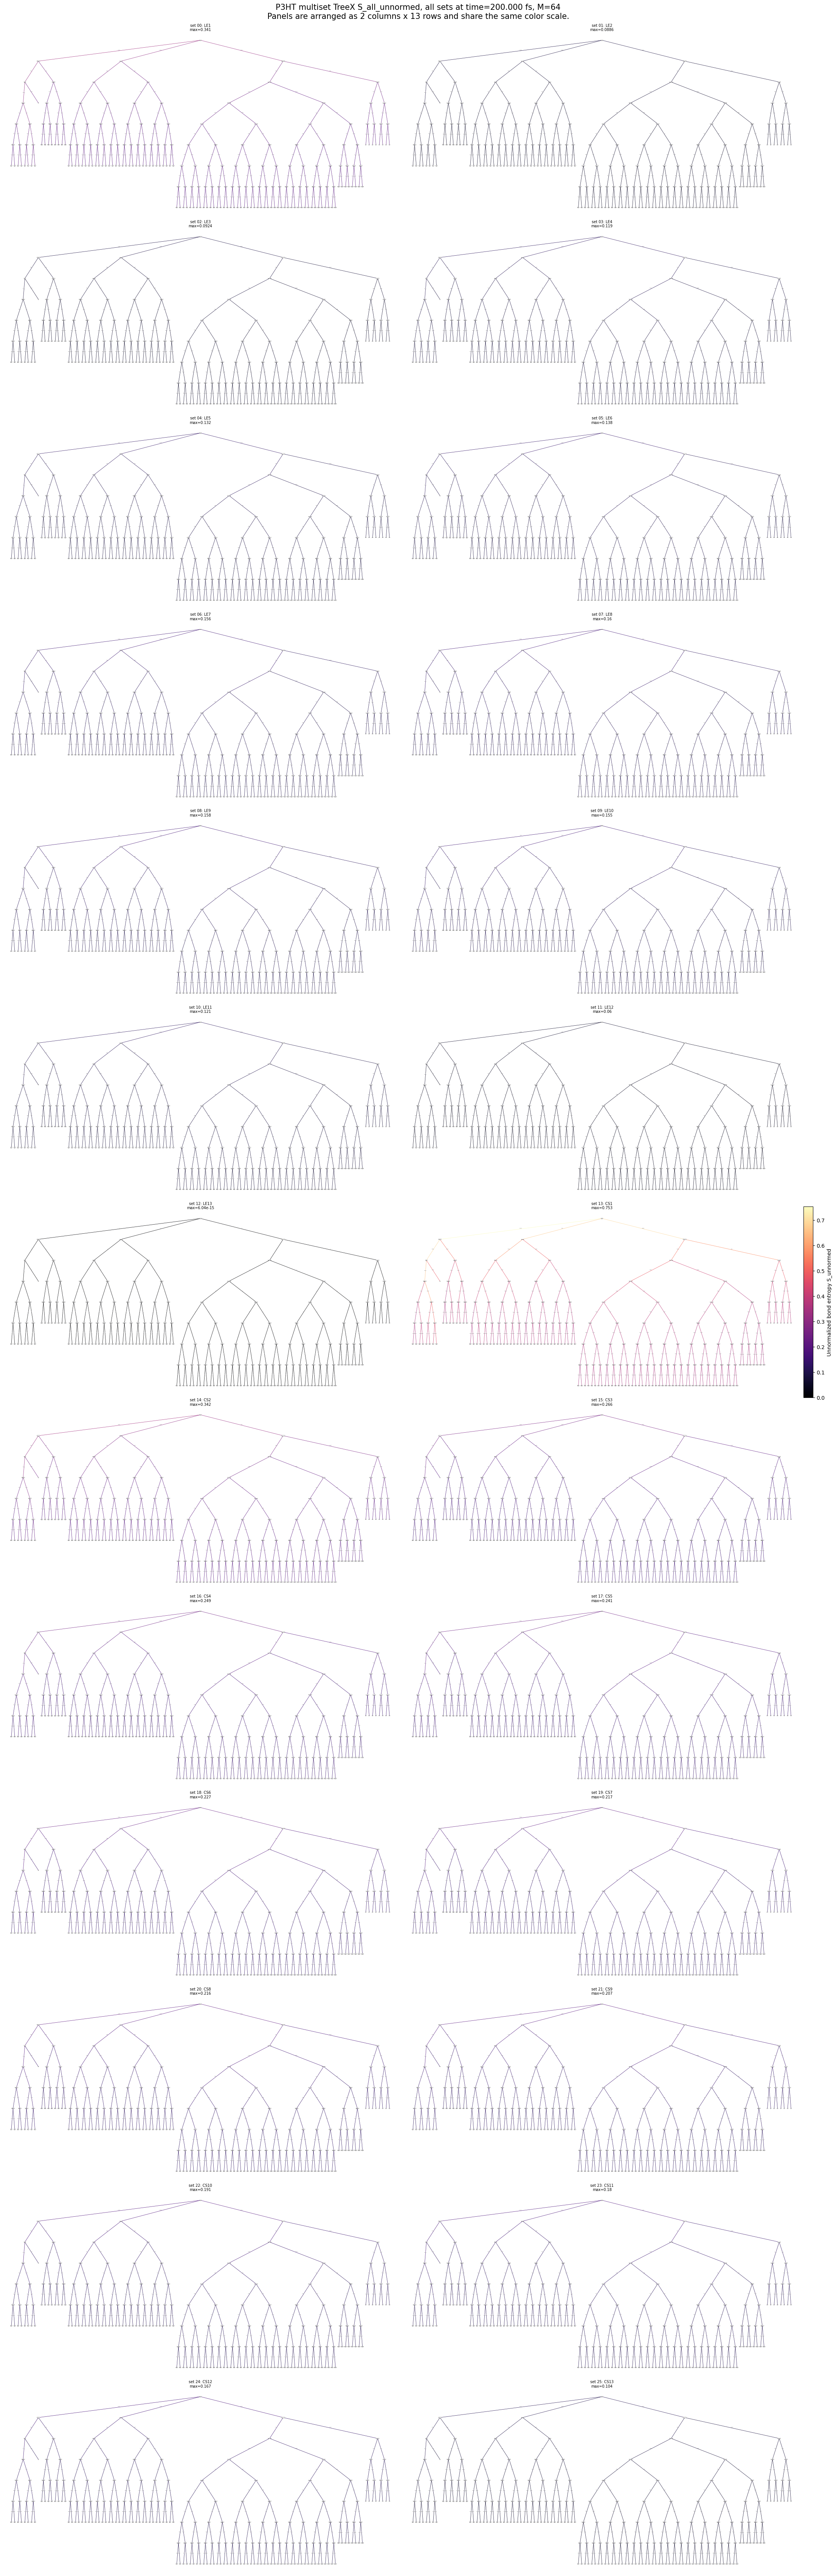

In [4]:
# Plot all 26 multiset TreeX bond-entropy trees in one 2x13 PDF.
# Color normalization is shared across all sets, so weakly entangled sets remain visibly pale.

MULTISET_ENTROPY_KEY = "S_all_unnormed"
MULTISET_MAX_BONDDIM = 64


def find_multiset_treeX_bond_entropy_dir():
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / "multiset_treeX_bond_entropy",
        cwd.parent / "multiset_treeX_bond_entropy",
        cwd / "multiset_ttn" / "P3HT:PCBM" / "multiset_treeX_bond_entropy",
    ]
    candidates.extend(parent / "multiset_ttn" / "P3HT:PCBM" / "multiset_treeX_bond_entropy" for parent in [cwd, *cwd.parents])
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(
        "Cannot find multiset_ttn/P3HT:PCBM/multiset_treeX_bond_entropy from the current notebook directory"
    )


def choose_multiset_treeX_npz(data_dir, max_bonddim=MULTISET_MAX_BONDDIM):
    npz_path = data_dir / f"p3ht_ms_ttn_treeX_bond_entropy_{max_bonddim}.npz"
    if not npz_path.exists():
        raise FileNotFoundError(f"Cannot find requested M={max_bonddim} file: {npz_path}")
    return max_bonddim, npz_path

def draw_tree_bond_entropy_panel(ax, raw_labels, children, edges, pos, entropies, norm, cmap, title):
    edge_entropies = np.array([entropies[child] for _, child in edges], dtype=float)

    for (parent, child), entropy in zip(edges, edge_entropies):
        x0, y0 = pos[parent]
        x1, y1 = pos[child]
        ax.plot(
            [x0, x1], [y0, y1],
            color=cmap(norm(entropy)),
            linewidth=0.52,
            solid_capstyle="round",
            zorder=1,
        )

        xm, ym = (x0 + x1) / 2.0, (y0 + y1) / 2.0
        dx, dy = x1 - x0, y1 - y0
        length = float(np.hypot(dx, dy))
        if length > 0:
            nx, ny = -dy / length, dx / length
            if ny < 0:
                nx, ny = -nx, -ny
        else:
            nx, ny = 0.0, 1.0
        ax.text(
            xm + 0.045 * nx,
            ym + 0.045 * ny,
            format_entropy(float(entropy)),
            ha="center",
            va="center",
            fontsize=1.65,
            color="#111111",
            bbox={"boxstyle": "round,pad=0.035", "facecolor": "white", "edgecolor": "none", "alpha": 0.68},
            zorder=2,
        )

    for idx, raw in enumerate(raw_labels):
        x, y = pos[idx]
        ax.text(
            x, y, short_node_label(raw),
            ha="center", va="center",
            fontsize=1.65,
            linespacing=0.82,
            bbox={"boxstyle": "round,pad=0.08", "facecolor": "white", "edgecolor": "#222222", "linewidth": 0.18},
            zorder=3,
        )

    ax.set_title(title, fontsize=7.0, pad=2.0)
    ax.set_axis_off()
    ax.margins(x=0.02, y=0.05)


multiset_data_dir = find_multiset_treeX_bond_entropy_dir()
max_bonddim, multiset_npz_path = choose_multiset_treeX_npz(multiset_data_dir)
multiset_npz = np.load(multiset_npz_path, allow_pickle=True)

entropy_key = MULTISET_ENTROPY_KEY
if entropy_key not in multiset_npz.files:
    fallback_key = "S_all"
    if fallback_key not in multiset_npz.files:
        raise KeyError(f"{multiset_npz_path.name} has neither {entropy_key!r} nor {fallback_key!r}")
    print(f"{entropy_key!r} not found; using {fallback_key!r} instead")
    entropy_key = fallback_key

raw_labels = [str(x) for x in multiset_npz["dof_strs"]]
adj = np.asarray(multiset_npz["adj_matrix"])
time_fs = np.asarray(multiset_npz["time_fs"], dtype=float)
step_idx = int(np.argmin(np.abs(time_fs - STEP)))
plot_time = float(time_fs[step_idx])
S_all_sets = np.asarray(multiset_npz[entropy_key], dtype=float)[step_idx]
state_labels = [str(x) for x in multiset_npz["state_labels"]] if "state_labels" in multiset_npz.files else []

nset = S_all_sets.shape[0]
if nset != 26:
    print(f"Warning: expected 26 sets, found {nset} sets in {multiset_npz_path.name}")

children = {idx: list(np.flatnonzero(adj[idx])) for idx in range(len(raw_labels))}
edges = [(parent, child) for parent, child_list in children.items() for child in child_list]
pos, n_leaves, max_depth = tree_layout(children, root=0)
all_edge_entropies = np.asarray([[entropies[child] for _, child in edges] for entropies in S_all_sets], dtype=float)
global_vmax = max(float(np.nanmax(all_edge_entropies)), 1e-12)
norm = mpl.colors.Normalize(vmin=0.0, vmax=global_vmax)
cmap = plt.get_cmap("magma")

plot_dir = multiset_data_dir.parent / "plot"
cbar_label = "Unnormalized bond entropy S_unnormed" if entropy_key == "S_all_unnormed" else "Bond entropy S"
out_pdf = plot_dir / f"p3ht_multiset_treeX_{entropy_key}_all_sets_step{int(round(plot_time))}_M{max_bonddim}.pdf"

print(
    f"Plotting {nset} multiset TreeX bond entropy trees from {multiset_npz_path.name}; "
    f"key={entropy_key}, requested STEP={STEP}, plotted time_fs={plot_time:.6f}, M={max_bonddim}, "
    f"shared_vmax={global_vmax:.6g}"
)

nrows, ncols = 13, 2
fig, axes = plt.subplots(nrows, ncols, figsize=(22, 68), constrained_layout=True)
axes = axes.ravel()

for iset, ax in enumerate(axes):
    if iset >= nset:
        ax.set_axis_off()
        continue
    state_label = state_labels[iset] if iset < len(state_labels) else f"set{iset}"
    set_max = float(np.nanmax(all_edge_entropies[iset])) if all_edge_entropies.size else 0.0
    title = f"set {iset:02d}: {state_label}\nmax={set_max:.3g}"
    draw_tree_bond_entropy_panel(ax, raw_labels, children, edges, pos, S_all_sets[iset], norm, cmap, title)

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.tolist(), fraction=0.012, pad=0.006)
cbar.set_label(cbar_label)

fig.suptitle(
    f"P3HT multiset TreeX {entropy_key}, all sets at time={plot_time:.3f} fs, M={max_bonddim}\n"
    "Panels are arranged as 2 columns x 13 rows and share the same color scale.",
    fontsize=15,
)
fig.savefig(out_pdf, bbox_inches="tight")
print(f"Saved figure to {out_pdf}")
plt.show()


In [ ]:
# Convert the previous M=64 unnormalized multiset TreeX bond entropy panel to normalized branch entropy.
# Formula: S_unnormed(alpha, bond) = p_alpha * S_normed(alpha, bond) - p_alpha * log(p_alpha).
# Therefore: S_normed(alpha, bond) = S_unnormed(alpha, bond) / p_alpha + log(p_alpha).

NORMALIZED_FROM_UNNORMED_MAX_BONDDIM = 64
NORMALIZED_FROM_UNNORMED_STEP = STEP
NORMALIZED_FROM_UNNORMED_KEY = "S_all_unnormed"

normalized_data_dir = find_multiset_treeX_bond_entropy_dir()
normalized_npz_path = normalized_data_dir / f"p3ht_ms_ttn_treeX_bond_entropy_{NORMALIZED_FROM_UNNORMED_MAX_BONDDIM}.npz"
if not normalized_npz_path.exists():
    raise FileNotFoundError(f"Cannot find M={NORMALIZED_FROM_UNNORMED_MAX_BONDDIM} data file: {normalized_npz_path}")

normalized_npz = np.load(normalized_npz_path, allow_pickle=True)
if NORMALIZED_FROM_UNNORMED_KEY not in normalized_npz.files:
    raise KeyError(f"{normalized_npz_path.name} has no {NORMALIZED_FROM_UNNORMED_KEY!r}")
if "e_occupations" not in normalized_npz.files:
    raise KeyError(f"{normalized_npz_path.name} has no 'e_occupations'")

raw_labels_normed = [str(x) for x in normalized_npz["dof_strs"]]
adj_normed = np.asarray(normalized_npz["adj_matrix"])
time_fs_normed = np.asarray(normalized_npz["time_fs"], dtype=float)
step_idx_normed = int(np.argmin(np.abs(time_fs_normed - NORMALIZED_FROM_UNNORMED_STEP)))
plot_time_normed = float(time_fs_normed[step_idx_normed])
populations_200fs = np.asarray(normalized_npz["e_occupations"], dtype=float)[step_idx_normed]

# Prefer the S_all_unnormed array produced by the previous block when that block was run with the same file/time.
use_previous_block_data = (
    "S_all_sets" in globals()
    and "multiset_npz_path" in globals()
    and Path(multiset_npz_path).resolve() == normalized_npz_path.resolve()
    and "entropy_key" in globals()
    and entropy_key == NORMALIZED_FROM_UNNORMED_KEY
    and "step_idx" in globals()
    and int(step_idx) == step_idx_normed
)
if use_previous_block_data:
    S_all_unnormed_at_step = np.asarray(S_all_sets, dtype=float)
else:
    S_all_unnormed_at_step = np.asarray(normalized_npz[NORMALIZED_FROM_UNNORMED_KEY], dtype=float)[step_idx_normed]

S_all_normed_from_unnormed = np.zeros_like(S_all_unnormed_at_step, dtype=float)
positive = populations_200fs > 0
S_all_normed_from_unnormed[positive] = (
    S_all_unnormed_at_step[positive] / populations_200fs[positive, None]
    + np.log(populations_200fs[positive])[:, None]
)
S_all_normed_from_unnormed[np.isclose(S_all_normed_from_unnormed, 0.0, atol=1e-12)] = 0.0
S_all_normed_from_unnormed = np.maximum(S_all_normed_from_unnormed, 0.0)

if "S_all_normed" in normalized_npz.files:
    stored_normed = np.asarray(normalized_npz["S_all_normed"], dtype=float)[step_idx_normed]
    max_abs_diff = float(np.nanmax(np.abs(S_all_normed_from_unnormed - stored_normed)))
    print(f"max |converted S_all_normed - stored S_all_normed| = {max_abs_diff:.6g}")

children_normed = {idx: list(np.flatnonzero(adj_normed[idx])) for idx in range(len(raw_labels_normed))}
edges_normed = [(parent, child) for parent, child_list in children_normed.items() for child in child_list]
pos_normed, n_leaves_normed, max_depth_normed = tree_layout(children_normed, root=0)
all_edge_entropies_normed = np.asarray(
    [[entropies[child] for _, child in edges_normed] for entropies in S_all_normed_from_unnormed],
    dtype=float,
)
global_vmax_normed = max(float(np.nanmax(all_edge_entropies_normed)), 1e-12)
norm_normed = mpl.colors.Normalize(vmin=0.0, vmax=global_vmax_normed)
cmap_normed = plt.get_cmap("magma")

state_labels_normed = [str(x) for x in normalized_npz["state_labels"]] if "state_labels" in normalized_npz.files else []
nset_normed = S_all_normed_from_unnormed.shape[0]
plot_dir = normalized_data_dir.parent / "plot"
out_pdf_normed = plot_dir / (
    f"p3ht_multiset_treeX_S_all_normed_from_unnormed_all_sets_"
    f"step{int(round(plot_time_normed))}_M{NORMALIZED_FROM_UNNORMED_MAX_BONDDIM}.pdf"
)

print(
    f"Plotting converted normalized branch entropy from {normalized_npz_path.name}; "
    f"requested STEP={NORMALIZED_FROM_UNNORMED_STEP}, plotted time_fs={plot_time_normed:.6f}, "
    f"M={NORMALIZED_FROM_UNNORMED_MAX_BONDDIM}, shared_vmax={global_vmax_normed:.6g}, "
    f"using_previous_block_data={use_previous_block_data}"
)

nrows, ncols = 13, 2
fig, axes = plt.subplots(nrows, ncols, figsize=(22, 68), constrained_layout=True)
axes = axes.ravel()

for iset, ax in enumerate(axes):
    if iset >= nset_normed:
        ax.set_axis_off()
        continue
    state_label = state_labels_normed[iset] if iset < len(state_labels_normed) else f"set{iset}"
    set_max = float(np.nanmax(all_edge_entropies_normed[iset])) if all_edge_entropies_normed.size else 0.0
    population = float(populations_200fs[iset]) if iset < len(populations_200fs) else float("nan")
    title = f"set {iset:02d}: {state_label}\np={population:.3g}, max={set_max:.3g}"
    draw_tree_bond_entropy_panel(
        ax,
        raw_labels_normed,
        children_normed,
        edges_normed,
        pos_normed,
        S_all_normed_from_unnormed[iset],
        norm_normed,
        cmap_normed,
        title,
    )

sm = mpl.cm.ScalarMappable(norm=norm_normed, cmap=cmap_normed)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.tolist(), fraction=0.012, pad=0.006)
cbar.set_label("Normalized branch bond entropy S_normed")

fig.suptitle(
    f"P3HT multiset TreeX S_all_normed converted from S_all_unnormed, all sets at "
    f"time={plot_time_normed:.3f} fs, M={NORMALIZED_FROM_UNNORMED_MAX_BONDDIM}\n"
    "Panels are arranged as 2 columns x 13 rows and share the same color scale.",
    fontsize=15,
)
fig.savefig(out_pdf_normed, bbox_inches="tight")
print(f"Saved figure to {out_pdf_normed}")
plt.show()
